In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("../data/insurance_cleaned.csv", low_memory=False)
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

print(f"Shape: {df.shape}")
print(f"\nOverall Claim Frequency: {df['HasClaim'].mean():.4f} ({df['HasClaim'].mean()*100:.2f}%)")
print(f"Overall Claim Severity: R{df[df['TotalClaims']>0]['TotalClaims'].mean():,.2f}")
print(f"Overall Margin: R{df['Margin'].mean():,.2f}")

Shape: (1000098, 53)

Overall Claim Frequency: 0.0028 (0.28%)
Overall Claim Severity: R23,273.39
Overall Margin: R-2.96


In [3]:
print("="*60)
print("H0: There are no risk differences across provinces")
print("="*60)

gauteng = df[df['Province'] == 'Gauteng']['TotalClaims']
western_cape = df[df['Province'] == 'Western Cape']['TotalClaims']

t_stat, p_value = stats.ttest_ind(gauteng, western_cape)

print(f"\nKPI: Claim Severity (TotalClaims)")
print(f"Group A — Gauteng:      mean = R{gauteng.mean():,.4f}, n={len(gauteng):,}")
print(f"Group B — Western Cape: mean = R{western_cape.mean():,.4f}, n={len(western_cape):,}")
print(f"\nTest: Independent t-test")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"\nDecision: {'✅ REJECT H0' if p_value < 0.05 else '❌ FAIL TO REJECT H0'} (alpha=0.05)")

if p_value < 0.05:
    lr_g = df[df['Province']=='Gauteng']['TotalClaims'].sum() / df[df['Province']=='Gauteng']['TotalPremium'].sum()
    lr_w = df[df['Province']=='Western Cape']['TotalClaims'].sum() / df[df['Province']=='Western Cape']['TotalPremium'].sum()
    diff = (lr_g - lr_w) / lr_w * 100
    print(f"\nBusiness Interpretation:")
    print(f"  Gauteng Loss Ratio:      {lr_g:.3f}")
    print(f"  Western Cape Loss Ratio: {lr_w:.3f}")
    print(f"  Gauteng is {diff:.1f}% higher risk than Western Cape.")
    print(f"  → Recommend regional premium adjustment for Gauteng.")

H0: There are no risk differences across provinces

KPI: Claim Severity (TotalClaims)
Group A — Gauteng:      mean = R74.6300, n=393,865
Group B — Western Cape: mean = R60.8315, n=170,796

Test: Independent t-test
T-statistic: 1.9086
P-value:     0.056320

Decision: ❌ FAIL TO REJECT H0 (alpha=0.05)


In [4]:
print("="*60)
print("H0: There are no risk differences between zip codes")
print("="*60)

# Get top 2 zip codes by policy count for fair comparison
top_zips = df['PostalCode'].value_counts().head(2).index.tolist()
zip1 = df[df['PostalCode'] == top_zips[0]]['TotalClaims']
zip2 = df[df['PostalCode'] == top_zips[1]]['TotalClaims']

t_stat, p_value = stats.ttest_ind(zip1, zip2)

print(f"\nKPI: Claim Severity (TotalClaims)")
print(f"Group A — PostalCode {top_zips[0]}: mean = R{zip1.mean():,.4f}, n={len(zip1):,}")
print(f"Group B — PostalCode {top_zips[1]}: mean = R{zip2.mean():,.4f}, n={len(zip2):,}")
print(f"\nTest: Independent t-test")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"\nDecision: {'✅ REJECT H0' if p_value < 0.05 else '❌ FAIL TO REJECT H0'} (alpha=0.05)")

if p_value < 0.05:
    print(f"\nBusiness Interpretation:")
    print(f"  Zip code is a statistically significant risk driver (p < 0.05).")
    print(f"  → PostalCode should be included as a feature in the pricing model.")
else:
    print(f"\nBusiness Interpretation:")
    print(f"  No significant difference detected between these two zip codes.")
    print(f"  → Zip code alone may not justify premium differentiation at this level.")

H0: There are no risk differences between zip codes

KPI: Claim Severity (TotalClaims)
Group A — PostalCode 2000: mean = R69.8846, n=133,498
Group B — PostalCode 122: mean = R77.5666, n=49,171

Test: Independent t-test
T-statistic: -0.6709
P-value:     0.502286

Decision: ❌ FAIL TO REJECT H0 (alpha=0.05)

Business Interpretation:
  No significant difference detected between these two zip codes.
  → Zip code alone may not justify premium differentiation at this level.


In [5]:
print("="*60)
print("H0: There is no significant margin difference between zip codes")
print("="*60)

margin1 = df[df['PostalCode'] == top_zips[0]]['Margin']
margin2 = df[df['PostalCode'] == top_zips[1]]['Margin']

t_stat, p_value = stats.ttest_ind(margin1, margin2)

print(f"\nKPI: Margin (TotalPremium - TotalClaims)")
print(f"Group A — PostalCode {top_zips[0]}: mean margin = R{margin1.mean():,.4f}, n={len(margin1):,}")
print(f"Group B — PostalCode {top_zips[1]}: mean margin = R{margin2.mean():,.4f}, n={len(margin2):,}")
print(f"\nTest: Independent t-test")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"\nDecision: {'✅ REJECT H0' if p_value < 0.05 else '❌ FAIL TO REJECT H0'} (alpha=0.05)")

if p_value < 0.05:
    print(f"\nBusiness Interpretation:")
    print(f"  Significant margin difference exists between zip codes.")
    print(f"  → Zip code-level margin analysis should inform marketing spend allocation.")

H0: There is no significant margin difference between zip codes

KPI: Margin (TotalPremium - TotalClaims)
Group A — PostalCode 2000: mean margin = R-8.1119, n=133,498
Group B — PostalCode 122: mean margin = R-22.8598, n=49,171

Test: Independent t-test
T-statistic: 1.2933
P-value:     0.195909

Decision: ❌ FAIL TO REJECT H0 (alpha=0.05)


In [6]:
print("="*60)
print("H0: There is no significant risk difference between Women and Men")
print("="*60)

male = df[df['Gender'] == 'Male']['TotalClaims']
female = df[df['Gender'] == 'Female']['TotalClaims']

t_stat, p_value = stats.ttest_ind(male, female)

print(f"\nKPI: Claim Severity (TotalClaims)")
print(f"Group A — Male:   mean = R{male.mean():,.4f}, n={len(male):,}")
print(f"Group B — Female: mean = R{female.mean():,.4f}, n={len(female):,}")
print(f"\nTest: Independent t-test")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"\nDecision: {'✅ REJECT H0' if p_value < 0.05 else '❌ FAIL TO REJECT H0'} (alpha=0.05)")

if p_value < 0.05:
    print(f"\nBusiness Interpretation:")
    print(f"  Gender is a statistically significant risk factor (p < 0.05).")
    print(f"  Male mean claim (R{male.mean():,.2f}) vs Female (R{female.mean():,.2f}).")
    print(f"  → Gender-adjusted premiums are statistically justified where legally permitted.")
else:
    print(f"\nBusiness Interpretation:")
    print(f"  No statistically significant difference in claim severity between genders.")
    print(f"  → Observed loss ratio differences may be due to portfolio composition, not risk.")

H0: There is no significant risk difference between Women and Men

KPI: Claim Severity (TotalClaims)
Group A — Male:   mean = R32.6203, n=42,817
Group B — Female: mean = R37.0461, n=6,755

Test: Independent t-test
T-statistic: -0.2480
P-value:     0.804107

Decision: ❌ FAIL TO REJECT H0 (alpha=0.05)

Business Interpretation:
  No statistically significant difference in claim severity between genders.
  → Observed loss ratio differences may be due to portfolio composition, not risk.


In [7]:
# Collect all p-values
results_data = []
tests = [
    ("H1: No risk diff across provinces", "t-test", "Claim Severity",
     "Gauteng vs Western Cape",
     stats.ttest_ind(df[df['Province']=='Gauteng']['TotalClaims'],
                     df[df['Province']=='Western Cape']['TotalClaims'])[1]),
    ("H2: No risk diff between zip codes", "t-test", "Claim Severity",
     f"{top_zips[0]} vs {top_zips[1]}",
     stats.ttest_ind(zip1, zip2)[1]),
    ("H3: No margin diff between zip codes", "t-test", "Margin",
     f"{top_zips[0]} vs {top_zips[1]}",
     stats.ttest_ind(margin1, margin2)[1]),
    ("H4: No risk diff between genders", "t-test", "Claim Severity",
     "Male vs Female",
     stats.ttest_ind(male, female)[1]),
]

results_df = pd.DataFrame(tests, columns=['Hypothesis', 'Test', 'KPI', 'Groups', 'P-Value'])
results_df['Decision'] = results_df['P-Value'].apply(
    lambda p: 'Reject H0' if p < 0.05 else 'Fail to Reject'
)
results_df['P-Value'] = results_df['P-Value'].apply(lambda p: f"{p:.6f}")

print("="*60)
print("HYPOTHESIS TESTING RESULTS SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

HYPOTHESIS TESTING RESULTS SUMMARY
                          Hypothesis   Test            KPI                  Groups  P-Value       Decision
   H1: No risk diff across provinces t-test Claim Severity Gauteng vs Western Cape 0.056320 Fail to Reject
  H2: No risk diff between zip codes t-test Claim Severity             2000 vs 122 0.502286 Fail to Reject
H3: No margin diff between zip codes t-test         Margin             2000 vs 122 0.195909 Fail to Reject
    H4: No risk diff between genders t-test Claim Severity          Male vs Female 0.804107 Fail to Reject


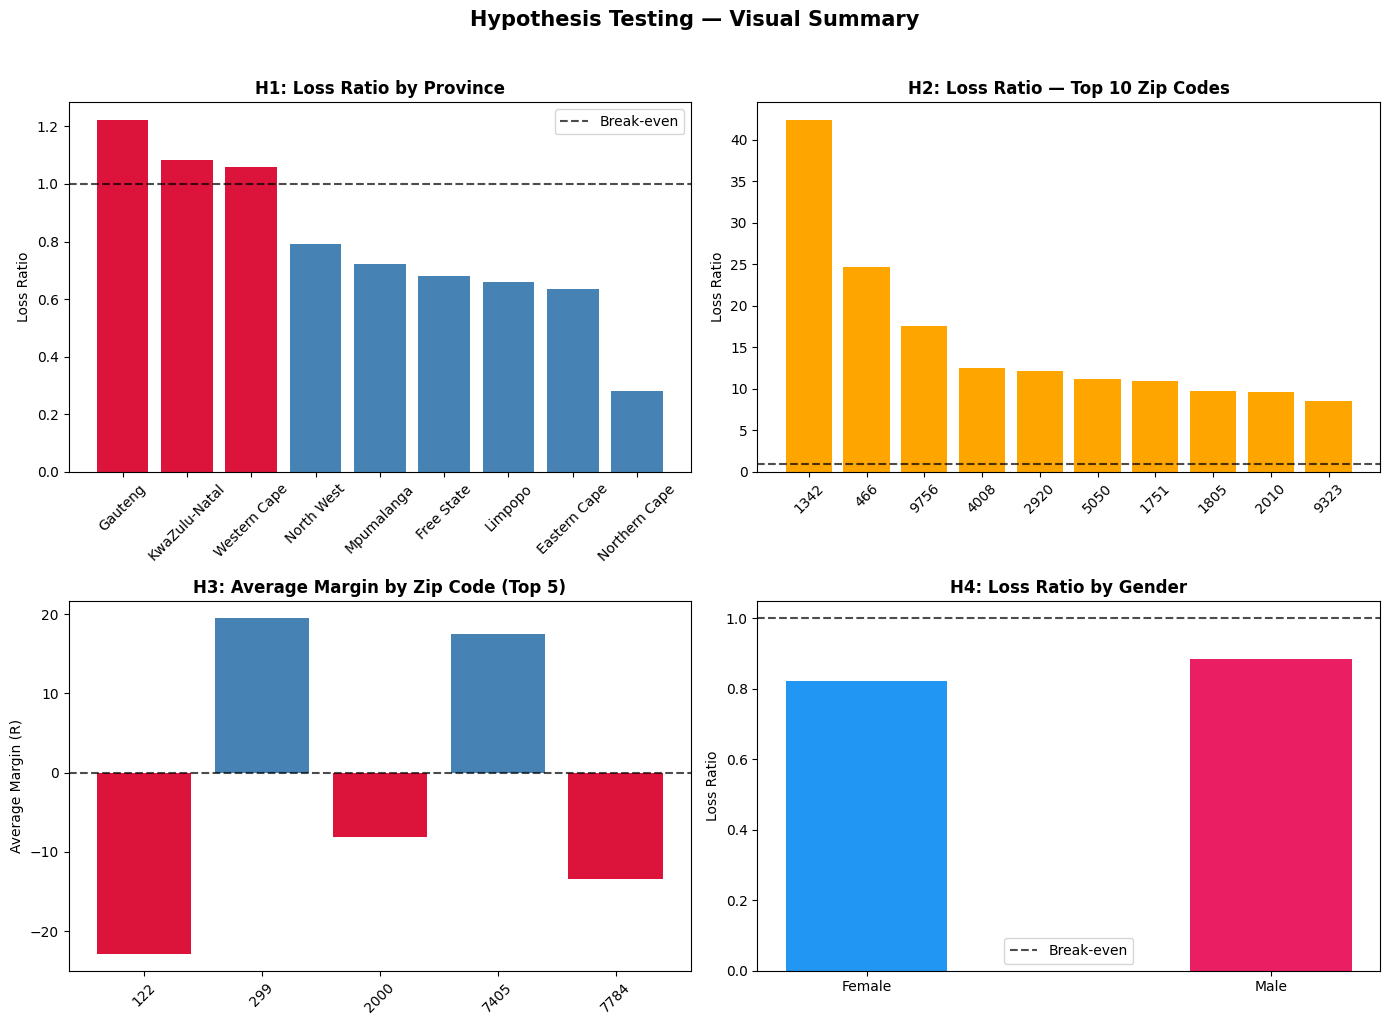

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# H1 - Province comparison
prov_lr = df.groupby('Province').apply(
    lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum()
).reset_index(name='LossRatio').sort_values('LossRatio', ascending=False)
colors_h1 = ['crimson' if lr > 1 else 'steelblue' for lr in prov_lr['LossRatio']]
axes[0,0].bar(prov_lr['Province'], prov_lr['LossRatio'], color=colors_h1)
axes[0,0].axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Break-even')
axes[0,0].set_title('H1: Loss Ratio by Province', fontweight='bold')
axes[0,0].set_ylabel('Loss Ratio')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

# H2 - Top zip codes
top10_zips = df.groupby('PostalCode').apply(
    lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum() if x['TotalPremium'].sum() > 0 else 0
).reset_index(name='LossRatio')
top10_zips = top10_zips[top10_zips['LossRatio'] > 0].nlargest(10, 'LossRatio')
axes[0,1].bar(top10_zips['PostalCode'].astype(str), top10_zips['LossRatio'], color='orange')
axes[0,1].axhline(1.0, color='black', linestyle='--', alpha=0.7)
axes[0,1].set_title('H2: Loss Ratio — Top 10 Zip Codes', fontweight='bold')
axes[0,1].set_ylabel('Loss Ratio')
axes[0,1].tick_params(axis='x', rotation=45)

# H3 - Margin by zip
top5_zips = df['PostalCode'].value_counts().head(5).index
margin_by_zip = df[df['PostalCode'].isin(top5_zips)].groupby('PostalCode')['Margin'].mean()
axes[1,0].bar(margin_by_zip.index.astype(str), margin_by_zip.values,
              color=['crimson' if m < 0 else 'steelblue' for m in margin_by_zip.values])
axes[1,0].axhline(0, color='black', linestyle='--', alpha=0.7)
axes[1,0].set_title('H3: Average Margin by Zip Code (Top 5)', fontweight='bold')
axes[1,0].set_ylabel('Average Margin (R)')
axes[1,0].tick_params(axis='x', rotation=45)

# H4 - Gender
gender_data = df[df['Gender'].isin(['Male', 'Female'])]
gender_lr = gender_data.groupby('Gender').apply(
    lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum()
).reset_index(name='LossRatio')
axes[1,1].bar(gender_lr['Gender'], gender_lr['LossRatio'],
              color=['#2196F3', '#E91E63'], width=0.4)
axes[1,1].axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Break-even')
axes[1,1].set_title('H4: Loss Ratio by Gender', fontweight='bold')
axes[1,1].set_ylabel('Loss Ratio')
axes[1,1].legend()

plt.suptitle('Hypothesis Testing — Visual Summary', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/hypothesis_testing_summary.png', dpi=150, bbox_inches='tight')
plt.show()